# Laboratorio 3 — Reconocimiento de Lenguaje de Señas ASL (SignBridge)

**CC3084 — Data Science | UVG | Semestre II 2026**

**Grupo:** Anggie Quezada Jonathan Díaz e Iris Ayala 

Este notebook cubre el **avance** del laboratorio

In [1]:
import os
import glob
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.model_selection import train_test_split

sns.set_style("whitegrid")
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

DATA_DIR = os.path.join("..", "data", "asl_alphabet_train", "asl_alphabet_train")

assert os.path.isdir(DATA_DIR), f"No encuentro {DATA_DIR}. Revisa el README para descargar el dataset."

CLASSES = sorted(os.listdir(DATA_DIR))
print(f"Clases encontradas ({len(CLASSES)}):")
print(CLASSES)


Clases encontradas (29):
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


## 1. Construir el índice de imágenes

Antes de hacer cualquier análisis, armamos un DataFrame con la ruta de cada imagen y su
clase (letra). Esto nos evita cargar las 87,000 imágenes en memoria de una vez.

In [2]:
records = []
for cls in CLASSES:
    cls_dir = os.path.join(DATA_DIR, cls)
    paths = glob.glob(os.path.join(cls_dir, "*.jpg"))
    for p in paths:
        records.append({"filepath": p, "label": cls})

df = pd.DataFrame(records)
print(f"Total de imágenes encontradas: {len(df):,}")
df.head()


Total de imágenes encontradas: 87,000


,filepath,label
0,../data/asl_alphabet_train/asl_alphabet_train/...,A
1,../data/asl_alphabet_train/asl_alphabet_train/...,A
2,../data/asl_alphabet_train/asl_alphabet_train/...,A
3,../data/asl_alphabet_train/asl_alphabet_train/...,A
4,../data/asl_alphabet_train/asl_alphabet_train/...,A


## Ejercicio 1 — Ejemplos de letras y variabilidad dentro de una clase

Mostramos al menos 5 letras distintas, con varias muestras de una misma letra para ver
qué tanto varía la seña (ángulo de mano, iluminación, fondo) dentro de una sola clase.

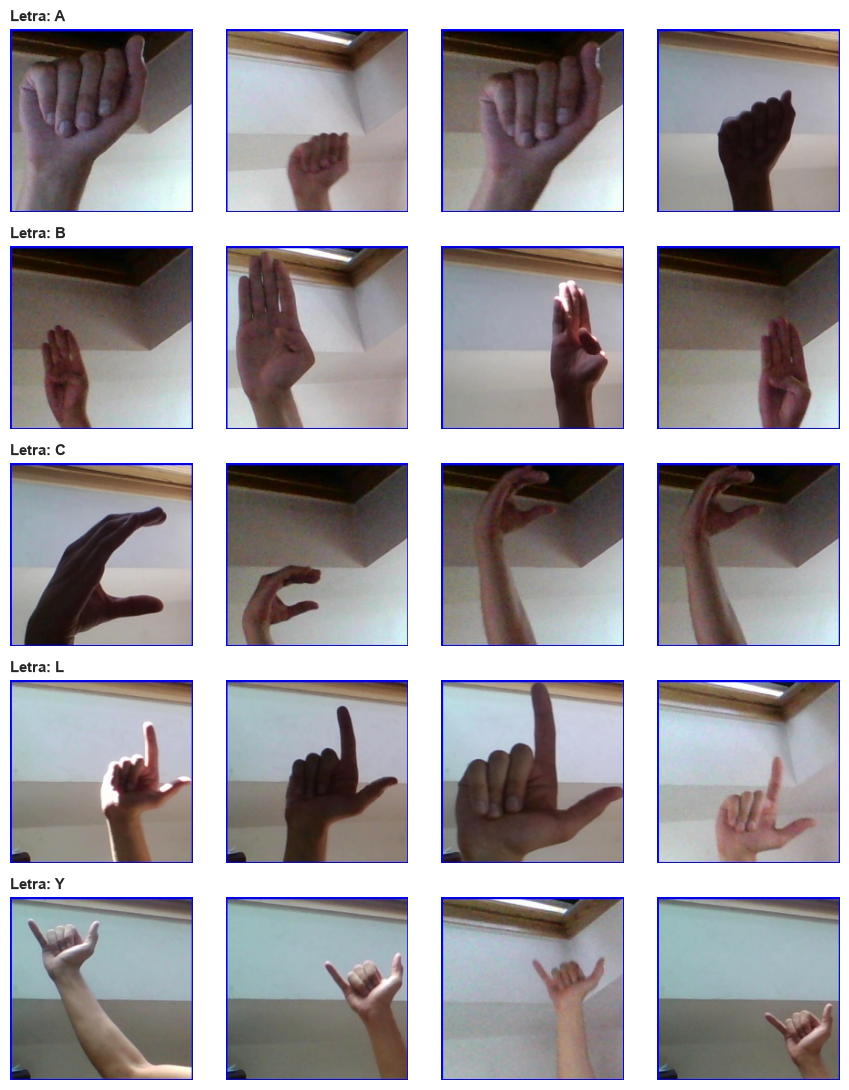

In [3]:
def show_letter_samples(letters, n_samples=4, seed=RANDOM_STATE):
    rng = random.Random(seed)
    fig, axes = plt.subplots(len(letters), n_samples, figsize=(n_samples * 2.2, len(letters) * 2.2))
    for i, letter in enumerate(letters):
        sample_paths = rng.sample(list(df[df.label == letter].filepath), n_samples)
        for j, p in enumerate(sample_paths):
            img = Image.open(p)
            ax = axes[i, j] if len(letters) > 1 else axes[j]
            ax.imshow(img)
            ax.axis("off")
            if j == 0:
                ax.set_ylabel(letter, fontsize=12)
        axes[i, 0].set_title(f"Letra: {letter}", loc="left", fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.show()

# 5 letras + varias muestras cada una, para ver variabilidad intra-clase
show_letter_samples(["A", "B", "C", "L", "Y"], n_samples=4)


**Hallazgo esperado:** dentro de una misma letra, las fotos varían en ángulo de la mano,
iluminación, tono de piel de quien hace la seña y fondo — pero la forma de la mano (la seña en sí)
se mantiene consistente. Esto es justo lo que necesitamos que el modelo aprenda a ignorar (fondo,
iluminación) para quedarse solo con la forma de la mano.

## Ejercicio 2 — Análisis exploratorio (EDA)

### 2.1 Resolución y formato de las imágenes